In [39]:
# read Cut2_1.csv and Cut2_2.csv, combine them with only "designation"
# save to new file Cut2_comb_12.csv

import pandas as pd
# read the two csv files
df1 = pd.read_csv('Cut2_1.csv')
print(df1['designation'][:3])
df2 = pd.read_csv('Cut2_2.csv')

df1_Gid = df1['designation']
df1_ra = df1['ra']
df1_dec = df1['dec']

df2_Gid = df2['designation']
df2_ra = df2['ra']
df2_dec = df2['dec']

# new_df1 = pd.DataFrame({'designation': df1_Gid, 'ra': df1_ra, 'dec': df1_dec})
# new_df2 = pd.DataFrame({'designation': df2_Gid, 'ra': df2_ra, 'dec': df2_dec})
# # combine the two dataframes
# combined_df = pd.concat([new_df1[['designation']], new_df2[['designation']]], ignore_index=True)
# # save the combined dataframe to a new csv file
# combined_df.to_csv('Cut2_comb_12.csv', index=False, header=False)

# print(len(combined_df))

# save only "ruwe" bigger than 1 to new file Cut2_comb_12_ruwe.csv

df1_f_ruwe = df1[(df1['ruwe'] > 1.4) & (df1['ruwe'] < 5)]
df2_f_ruwe = df2[(df2['ruwe'] > 1.4) & (df2['ruwe'] < 5)]

new_df1_f_ruwe = pd.DataFrame({'designation': df1_f_ruwe['designation']})
new_df2_f_ruwe = pd.DataFrame({'designation': df2_f_ruwe['designation']})
combined_df_f_ruwe = pd.concat([new_df1_f_ruwe, new_df2_f_ruwe], ignore_index=True)
combined_df_f_ruwe.to_csv('Cut2_comb_12_ruwe.csv', index=False, header=False)
print(len(combined_df_f_ruwe))

df1_f_ruwe = df1[df1['non_single_star'] != 0]
df2_f_ruwe = df2[df2['non_single_star']  != 0]

new_df1_f_ruwe = pd.DataFrame({'designation': df1_f_ruwe['designation'], 
                               'ruwe': df1_f_ruwe['ruwe'], 
                               'non_single_star': df1_f_ruwe['non_single_star']})

new_df2_f_ruwe = pd.DataFrame({'designation': df2_f_ruwe['designation'], 
                                 'ruwe': df2_f_ruwe['ruwe'], 
                                 'non_single_star': df2_f_ruwe['non_single_star']})

combined_df_f_non_single_star = (pd.concat([new_df1_f_ruwe, new_df2_f_ruwe], ignore_index=True))
combined_df_f_non_single_star = combined_df_f_non_single_star.sort_values(by='ruwe', ascending=False)
combined_df_f_non_single_star.to_csv('Cut2_comb_12_non_single_star.csv', index=False)
print(len(combined_df_f_non_single_star))

#check if 'designation' in combined_df_f_non_single_star is unique
print(combined_df_f_non_single_star['designation'].is_unique)

#make designation is unique 
combined_df_f_non_single_star_unique = combined_df_f_non_single_star.drop_duplicates(subset='designation', keep='first')
# combined_df_f_non_single_star_unique = combined_df_f_non_single_star_unique['designation']
combined_df_f_non_single_star_unique.to_csv('Cut2_comb_12_non_single_star_unique.csv', 
                                            index=False, 
                                        header=True)
print(len(combined_df_f_non_single_star_unique))

0    Gaia DR3 1305304440305268992
1    Gaia DR3 1303707330945926912
2    Gaia DR3 1319031877337233536
Name: designation, dtype: object
308
189
False
157


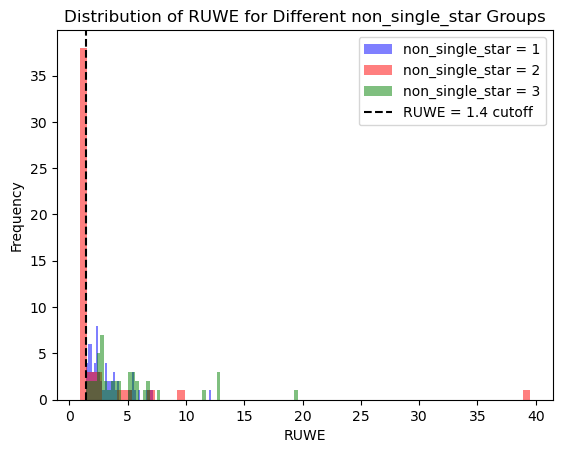

In [6]:
# read cut**unique.csv and plot ruwe vs non_single_star
import matplotlib.pyplot as plt
import pandas as pd
file_non_single_star = 'Cut2_comb_12_non_single_star_unique.csv'
df_non_single_star = pd.read_csv(file_non_single_star)
ruwe = df_non_single_star['ruwe'].values
non_single_star = df_non_single_star['non_single_star'].values
#separate non_single_star into 3 groups: 1, 2, 3
group1 = df_non_single_star[df_non_single_star['non_single_star'] == 1]
group2 = df_non_single_star[df_non_single_star['non_single_star'] == 2]
group3 = df_non_single_star[df_non_single_star['non_single_star'] == 3]

plt.hist(group1['ruwe'], bins=60, alpha=0.5, label='non_single_star = 1',color='blue')
plt.hist(group2['ruwe'], bins=60, alpha=0.5, label='non_single_star = 2',color='red')
plt.hist(group3['ruwe'], bins=60, alpha=0.5, label='non_single_star = 3',color='green')
#plot the cutoff line of ruwe = 1.4
plt.axvline(x=1.4, color='black', linestyle='--', label='RUWE = 1.4 cutoff')
plt.xlabel('RUWE')
plt.ylabel('Frequency')
plt.title('Distribution of RUWE for Different non_single_star Groups')
plt.legend()
plt.show()